# 03 — Combined 2μ2e·4μ VR DATA Release Review

Define the VRs and release scope before examining DATA κ. Do not sum yields across channels.
The common projection/ABCD core from 01·02 is included here so this notebook can run independently; the earlier notebooks do not need to be executed.

- Mass inclusive (including underflow), |Δφ|≥2, with the existing displacement definitions.
- Fix only the ABCD boundary of the other isolation axis at 0.5. This is not an iso<0.5 event preselection.
- A=pass/pass, B=fail/pass, C=pass/fail, D=fail/fail; pass means iso<threshold, with flow bins included.
- The default run performs only the MC review. Do not load DATA while the release policy is undecided.
- Overlapping WPs/profiles are not independent measurements. Do not select only points with κ≈1.


In [1]:
from pathlib import Path
from dataclasses import dataclass
import gc
import sys
import json
from datetime import datetime, timezone

SIDM_DIR = next((p for p in (Path.cwd(), *Path.cwd().parents) if p.name == "sidm"), None)
if SIDM_DIR is None:
    raise RuntimeError("Run this notebook from within the sidm repository.")
if str(SIDM_DIR.parent) not in sys.path:
    sys.path.insert(0, str(SIDM_DIR.parent))
import coffea.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm
from matplotlib.patches import Rectangle
from IPython.display import display

if int(np.__version__.split(".")[0]) < 2:
    import numpy.core as _numpy_core
    import numpy.core.multiarray as _numpy_multiarray
    import numpy.core.numeric as _numpy_numeric
    sys.modules.setdefault("numpy._core", _numpy_core)
    sys.modules.setdefault("numpy._core.multiarray", _numpy_multiarray)
    sys.modules.setdefault("numpy._core.numeric", _numpy_numeric)
plt.rcParams.update({"figure.dpi": 100, "font.size": 10, "axes.spines.top": True,
                     "axes.spines.right": True, "pdf.fonttype": 42})
pd.set_option("display.max_columns", 18)

## 1. Policy and Settings Pending Agreement

SIGNAL_SCALE is an additional scale factor on the stored yields; SIGNAL_STRENGTH is the μ applied on top of it.
μ=1 is the diagnostic default for the stored normalization and does not imply that the normalization has been verified.
Diagnose all 180 hypotheses (including both decay topologies) individually. Do not sum signals.
POLICY_SIGNALS=None uses all hypotheses for the policy. When using a subset, specify the sample list and rationale for each channel.

The acceptance criterion is S/B, which differs from the existing S/(S+B)≤0.10 criterion (the latter is equivalent to S/B≤1/9).
The limit remains None until agreement is reached. Normalization verification, a policy rationale, and team agreement are also required.
PROTECTED_SR defaults to all candidates from 01·02. The 4μ pixel2 VR overlaps the pixel3 SR.
Update the list after the team finalizes the protected SRs. Evaluate statistical support and release safety separately.
The release decision uses the S/B criterion for each region. Prediction changes are retained only as reference diagnostics;
neither configuring a limit on them nor requiring them to be finite is a condition for release.



In [2]:
CAMPAIGN = "ABCD_6D_inclusive_eHEM_skimv1_v1"
INPUT_BASE = SIDM_DIR / "studies/ABCD_plane_summary"
TOPOLOGY = '2mu2e'
TOPOLOGY_LABEL = '2μ2e'
X_LABEL, Y_LABEL = ('μ-LJ isolation', 'eγ-LJ isolation')
PIXEL_WPS = (2,)
VARS = ("iso0", "iso1", "disp0", "disp1", "abs_dphi", "ljlj_mass")
EDGES = {
    "iso": np.array([0, .05, .1, .15, .2, .25, .3, .4, .5, .75, 1, 2, 5]),
    "pixel": np.arange(-.5, 12, 1, dtype=float),
    "lost": np.arange(-.5, 10, 1, dtype=float),
    "abs_dphi": np.array([0, .5, 1, 1.5, 2, 2.2, 2.4, 2.6, 2.7, 2.8, 2.9, 3, 3.05, 3.1, np.pi]),
    "ljlj_mass": np.array([0, 50, 100, 150, 200, 300, 400, 600, 800, 1000, 1500, 2500], float),
}
ISO_CUTS = EDGES["iso"][1:]
DISPLAY_WP = (.5, .5)  # Loose reference point; not an optimized or final WP.
DISPLAY_PROFILE = "pixel2"
ONE_D_FIXED = (.5,)  # Fix only the other isolation boundary in the 1D scan.
MIN_NEFF = 10.
MAX_SIGNAL_FRACTION = .10
SIGNAL_REFERENCES = {
    "2mu2e": {"prompt": "2Mu2E_1000GeV_0p25GeV_0p002mm", "displaced": "2Mu2E_1000GeV_0p25GeV_0p2mm"},
    "4mu": {"prompt": "4Mu_1000GeV_0p25GeV_0p002mm", "displaced": "4Mu_1000GeV_0p25GeV_0p2mm"},
}
SIGNAL_SCALE = {}
SIGNAL_NORMALIZATION_VERIFIED = False
LOAD_ALL_SIGNALS = True
CLOSURE_YLIM = (0, 2)
CHANNELS = {"2mu2e": (2,), "4mu": (2, 3)}
PROTECTED_SR = {"2mu2e": (2,), "4mu": (2, 3)}
SIGNAL_STRENGTH = 1.
POLICY_SIGNALS = None  # or {"2mu2e": [...], "4mu": [...]}
MAX_REGION_S_OVER_B = None  # VR ABCD and SR BCD
POLICY_CONFIRMED = False
POLICY_NOTE = ""
RUN_DATA = False
APPROVED_POINTS = []  # (channel, profile, tx, ty), Finalize before examining DATA
EXPORT_TABLES = False
OUTPUT_DIR = INPUT_BASE / "03_VR_data_safety"

# Same closure format as 01·02. Show contamination diagnostics in separate plots.
SAVE_FIGURES = False
FIGURE_DIR = OUTPUT_DIR / "figures"
PLOT_ISO_MAX = None  # For a display-only limit, e.g. 1.; retain the full scan and release decision


## 2. Existing Common Core

The same core as in 01·02 is included here. Set TOPOLOGY immediately before the calculations for each channel.
The existing gate based on two representative hypotheses is used only as a comparison diagnostic. Call the DATA helper only in the final optional execution step.


In [3]:
@dataclass
class Plane:
    """Iso–iso sumw and sumw2, including flow bins, and the edges of both axes."""
    w: np.ndarray
    v: np.ndarray
    ex: np.ndarray
    ey: np.ndarray


def _axis_edges(variable):
    if variable in ("iso0", "iso1"):
        return EDGES["iso"]
    if variable in ("disp0", "disp1"):
        return EDGES["lost" if TOPOLOGY == "2mu2e" and variable == "disp1" else "pixel"]
    return EDGES[variable]


def _split(edges, threshold):
    locations = np.flatnonzero(np.isclose(edges, float(threshold), rtol=0, atol=1e-12))
    if len(locations) != 1:
        raise ValueError(f"Threshold is not a stored bin edge: {threshold}")
    return int(locations[0]) + 1


def make_profiles():
    return [dict(profile=f"pixel{pixel:g}", mass_min=None, dphi_min=2., pixel_max=float(pixel))
            for pixel in PIXEL_WPS]


def _source_paths(source):
    directory = INPUT_BASE / f"{CAMPAIGN}_{source}_merged_samples_v1"
    paths = sorted(directory.glob("*.coffea"))
    expected = {"bkg": 18, "data": 68, "signal": 180}[source]
    if len(paths) != expected or any(path.stat().st_size <= 0 for path in paths):
        raise RuntimeError(f"Input file count/size mismatch: {source}; {len(paths)}/{expected}; {directory}")
    return paths


def _background_group(sample):
    if sample.startswith("QCD_"):
        return "QCD"
    if sample.startswith("DYJetsTo"):
        return "DY"
    if sample == "TTJets":
        return "TTJets"
    if sample in {"WW", "WZ", "ZZ"}:
        return "Diboson"
    raise ValueError(f"Unclassified background sample: {sample}")


def _inventory_row(path, source, group, loaded=True, scale=1.):
    return dict(source=source, sample=path.stem, group=group, file=str(path),
                bytes=path.stat().st_size, loaded=loaded, scale=scale,
                metadata_file=path.with_suffix(".meta.yaml").is_file())


def _load_cube(path, source):
    """For DATA, check only the common schema here. Apply numerical checks to the selected slice."""
    payload = coffea.util.load(path)
    if not isinstance(payload, dict) or set(payload.get("out", {})) != {path.stem}:
        raise ValueError(f"Sample identity mismatch: {path}")
    out = payload["out"][path.stem]
    expected = {f"abcd6d_{t}" for t in ("2mu2e", "4mu")} | {
        f"abcd6d_ref_{t}_{pair}" for t in ("2mu2e", "4mu")
        for pair in ("iso0_vs_iso1", "iso0_vs_abs_dphi", "disp0_vs_disp1")}
    if set(out["hists"]) != expected:
        raise ValueError(f"6D campaign histogram key mismatch: {path}")
    metadata = out["metadata"]
    if set(metadata["is_data"]) != {source == "data"}:
        raise ValueError(f"is_data metadata mismatch: {path}")
    if set(metadata["unweighted_hist"]) != {False}:
        raise ValueError(f"A weighted histogram is required: {path}")
    if {str(value) for value in metadata["year"]} != {"2018"}:
        raise ValueError(f"Year metadata mismatch: {path}")
    if any(h.storage_type.__name__ != "Weight" for h in out["hists"].values()):
        raise ValueError(f"Weight storage mismatch: {path}")
    histogram = out["hists"][f"abcd6d_{TOPOLOGY}"]
    if tuple(a.name for a in histogram.axes) != ("channel",) + tuple(VARS):
        raise ValueError(f"6D axis order mismatch: {path}")
    axis = histogram.axes["channel"]
    channel = f"abcd6d_inclusive_{TOPOLOGY}_dxySpread_cosAlpha_mu_veto_eHEM"
    if (not axis.traits.discrete or axis.traits.underflow or axis.traits.overflow
            or list(axis) != [channel]):
        raise ValueError(f"Topology channel mismatch: {path}")
    for variable in VARS:
        axis, edges = histogram.axes[variable], _axis_edges(variable)
        if not (axis.traits.underflow and axis.traits.overflow):
            raise ValueError(f"Missing flow bins: {path}/{variable}")
        if np.shape(axis.edges) != np.shape(edges) or not np.allclose(
                axis.edges, edges, rtol=0, atol=1e-12):
            raise ValueError(f"Frozen bin edge mismatch: {path}/{variable}")
    values, variances = histogram.values(flow=True), histogram.variances(flow=True)
    shape = (1,) + tuple(len(_axis_edges(variable)) + 1 for variable in VARS)
    if variances is None or values.shape != shape or variances.shape != shape:
        raise ValueError(f"sumw2/shape mismatch: {path}")
    # The ndarray view retains the histogram storage, so the payloads for the other topology can be released.
    return values[0], variances[0]


def _validate_storage(weights, variances):
    if not np.isfinite(weights).all() or not np.isfinite(variances).all():
        raise ValueError("The selected histogram contains nonfinite values.")
    if np.any(variances < 0):
        raise ValueError("The selected histogram contains negative sumw2 values.")


def _projection(weights, variances, profile, context):
    if context not in {"SR", "VR"}:
        raise ValueError(context)
    pixel_edge = profile["pixel_max"] + .5
    pixel_split = _split(_axis_edges("disp0"), pixel_edge)
    if TOPOLOGY == "2mu2e":
        second_split = _split(_axis_edges("disp1"), .5)  # lost hits >= 1
        second = slice(second_split, None) if context == "SR" else slice(None, second_split)
    else:
        second_split = _split(_axis_edges("disp1"), pixel_edge)
        second = slice(None, second_split) if context == "SR" else slice(second_split, None)
    first = slice(None, pixel_split) if context == "SR" else slice(pixel_split, None)
    dphi = slice(_split(_axis_edges("abs_dphi"), profile["dphi_min"]), None)
    mass = (slice(None) if profile["mass_min"] is None else
            slice(_split(_axis_edges("ljlj_mass"), profile["mass_min"]), None))
    selected = (slice(None), slice(None), first, second, dphi, mass)
    w, v = weights[selected], variances[selected]
    _validate_storage(w, v)
    # SR and VR each combine the two displacement conditions with AND.
    return Plane(w.sum(axis=(2, 3, 4, 5)), v.sum(axis=(2, 3, 4, 5)),
                 np.asarray(EDGES["iso"]), np.asarray(EDGES["iso"]))


def _add_plane(planes, key, plane):
    if key not in planes:
        planes[key] = Plane(plane.w.copy(), plane.v.copy(), plane.ex.copy(), plane.ey.copy())
    else:
        target = planes[key]
        if not np.array_equal(target.ex, plane.ex) or not np.array_equal(target.ey, plane.ey):
            raise ValueError("The planes being summed have different binning.")
        target.w += plane.w
        target.v += plane.v


def load_mc(profiles):
    """Retain only 2D projections: individual components and totals for background, and individual hypotheses for signal."""
    planes, inventory_rows, signal_inclusive = {}, [], {}
    references = set(SIGNAL_REFERENCES[TOPOLOGY].values())
    signal_paths = _source_paths("signal")
    if not references <= {path.stem for path in signal_paths}:
        raise RuntimeError("Required prompt/displaced reference signals are missing.")
    if not LOAD_ALL_SIGNALS:
        signal_paths = [path for path in signal_paths if path.stem in references]
    paths = [("bkg", path) for path in _source_paths("bkg")] + [
        ("signal", path) for path in signal_paths]
    for index, (source, path) in enumerate(paths, 1):
        weights, variances = _load_cube(path, source)
        _validate_storage(weights, variances)
        group = _background_group(path.stem) if source == "bkg" else path.stem
        scale = float(SIGNAL_SCALE.get(path.stem, 1.)) if source == "signal" else 1.
        if not np.isfinite(scale) or scale <= 0:
            raise ValueError(f"A positive finite signal scale is required: {path.stem}")
        if source == "signal":
            signal_inclusive[path.stem] = float(weights.sum()) * scale
        for profile in profiles:
            for context in ("SR", "VR"):
                plane = _projection(weights, variances, profile, context)
                if scale != 1.:
                    plane.w *= scale
                    plane.v *= scale**2
                _add_plane(planes, (group, profile["profile"], context), plane)
                if source == "bkg":
                    _add_plane(planes, ("BKG", profile["profile"], context), plane)
        inventory_rows.append(_inventory_row(path, source, group, scale=scale))
        del weights, variances
        gc.collect()
        if index % 20 == 0 or index == len(paths):
            print(f"Loading MC: {index}/{len(paths)}")
    return planes, [path.stem for path in signal_paths], pd.DataFrame(inventory_rows), signal_inclusive


def _quadrants(plane, tx, ty):
    ix, iy = _split(plane.ex, tx), _split(plane.ey, ty)
    slices = {"A": (slice(None, ix), slice(None, iy)),
              "B": (slice(ix, None), slice(None, iy)),
              "C": (slice(None, ix), slice(iy, None)),
              "D": (slice(ix, None), slice(iy, None))}
    _validate_storage(plane.w, plane.v)
    result = {}
    for region, index in slices.items():
        value, variance = float(plane.w[index].sum()), float(plane.v[index].sum())
        neff = value**2 / variance if variance > 0 else 0. if value == 0 else np.nan
        result[region] = dict(value=value, variance=variance, neff=neff)
    return result


def _empty_metrics(tx, ty, status):
    result = dict(threshold_x=float(tx), threshold_y=float(ty), pred=np.nan,
                  pred_error=np.nan, kappa=np.nan, kappa_error=np.nan, pull=np.nan,
                  min_neff=np.nan, min_sideband_neff=np.nan, low_stat=np.nan,
                  status=status, kappa_status=status)
    for region in "ABCD":
        result.update({region: np.nan, "var_" + region: np.nan,
                       "neff_" + region: np.nan, region + "_error": np.nan})
    return result


def metrics(plane, tx, ty):
    stats = _quadrants(plane, tx, ty)
    result = _empty_metrics(tx, ty, "EMPTY_OR_NONPOSITIVE_SIDEBAND")
    for region, item in stats.items():
        result.update({region: item["value"], "var_" + region: item["variance"],
                       "neff_" + region: item["neff"], region + "_error": np.sqrt(item["variance"])})
    neffs = np.array([stats[r]["neff"] for r in "ABCD"])
    result.update(min_neff=float(np.min(neffs)), min_sideband_neff=float(np.min(neffs[1:])),
                  low_stat=bool(not np.all(np.isfinite(neffs) & (neffs >= MIN_NEFF))))
    a, b, c, d = (stats[r]["value"] for r in "ABCD")
    va, vb, vc, vd = (stats[r]["variance"] for r in "ABCD")
    if not all(np.isfinite(value) and value > 0 for value in (b, c, d)):
        return result
    pred = b * c / d
    vp = (c / d)**2 * vb + (b / d)**2 * vc + (b * c / d**2)**2 * vd
    if not np.isfinite(pred) or pred <= 0 or not np.isfinite(vp):
        result.update(status="UNDEFINED_PREDICTION", kappa_status="UNDEFINED_PREDICTION")
        return result
    result.update(pred=pred, pred_error=np.sqrt(vp),
                  status="OK" if np.all(np.isfinite(neffs[1:]) & (neffs[1:] >= MIN_NEFF))
                  else "LOW_STAT_SIDEBAND")
    if a <= 0:
        result["kappa_status"] = "EMPTY_OR_NONPOSITIVE_A"
        return result
    kappa_variance = va / pred**2 + a**2 * vp / pred**4
    result.update(kappa=a / pred, kappa_error=np.sqrt(kappa_variance),
                  kappa_status="LOW_STAT" if result["low_stat"] else "OK",
                  pull=(a - pred) / np.sqrt(va + vp) if va + vp > 0 else np.nan)
    return result


def signal_metrics(signalplane, bkgplane, tx, ty, inclusive):
    signal, background = _quadrants(signalplane, tx, ty), _quadrants(bkgplane, tx, ty)
    result = dict(leakage=np.nan, leakage_error=np.nan, eff_A=np.nan, s_over_b=np.nan,
                  prediction_inflation=np.nan, signal_total=np.nan, signal_status="UNSUPPORTED")
    for region, item in signal.items():
        result.update({"signal_" + region: item["value"],
                       "signal_var_" + region: item["variance"], "signal_neff_" + region: item["neff"]})
    values = np.array([signal[r]["value"] for r in "ABCD"])
    if not np.isfinite(values).all() or np.any(values < 0):
        result["signal_status"] = "NEGATIVE_OR_UNDEFINED_SIGNAL"
        return result
    a, sb, sc, sd = values
    total = float(values.sum())
    result["signal_total"] = total
    if total <= 0:
        result["signal_status"] = "EMPTY_SIGNAL"
        return result
    leak, va = sb + sc + sd, signal["A"]["variance"]
    vl = sum(signal[r]["variance"] for r in "BCD")
    result.update(leakage=leak / total, leakage_error=np.sqrt((a*a*vl + leak*leak*va) / total**4),
                  eff_A=a / inclusive if np.isfinite(inclusive) and inclusive > 0 else np.nan,
                  signal_status="OK" if all(signal[r]["neff"] >= MIN_NEFF for r in "ABCD") else "LOW_STAT")
    if not np.isfinite(inclusive) or inclusive <= 0:
        result["signal_status"] = "NONPOSITIVE_OR_UNDEFINED_INCLUSIVE"
    ba, b, c, d = (background[r]["value"] for r in "ABCD")
    if ba > 0:
        result["s_over_b"] = a / ba
    if all(np.isfinite(value) and value > 0 for value in (b, c, d)):
        pred = b * c / d
        if np.isfinite(pred) and pred > 0:
            result["prediction_inflation"] = ((b + sb) * (c + sc) / (d + sd)) / pred - 1
    return result


def _signal_gate(background, signals):
    reasons, fractions = [], []
    for role in ("prompt", "displaced"):
        for context, regions in (("SR", "BCD"), ("VR", "ABCD")):
            for region in regions:
                b = background[context][region]
                s = signals[(role, context)]["signal_" + region]
                label = f"{role}_{context}_{region}"
                if not np.isfinite(b) or b <= 0:
                    reasons.append(label + ":nonpositive_or_undefined_background")
                elif not np.isfinite(s) or s < 0:
                    reasons.append(label + ":negative_or_undefined_signal")
                else:
                    fraction = s / (s + b)
                    fractions.append((fraction, label))
                    if fraction > MAX_SIGNAL_FRACTION and not np.isclose(
                            fraction, MAX_SIGNAL_FRACTION, rtol=0, atol=2*np.finfo(float).eps):
                        reasons.append(label + ":signal_fraction_exceeds_limit")
    return dict(gate_passed=not reasons, gate_reason="; ".join(reasons),
                gate_max_fraction=max(fractions)[0] if fractions else np.nan,
                gate_worst=max(fractions)[1] if fractions else "UNDEFINED")


def make_mc_scan(planes, profiles, signal_inclusive):
    if not 0 < MAX_SIGNAL_FRACTION < 1:
        raise ValueError("MAX_SIGNAL_FRACTION must be between 0 and 1.")
    rows = []
    for profile in profiles:
        name = profile["profile"]
        for tx in ISO_CUTS:
            for ty in ISO_CUTS:
                row = dict(profile, tx=float(tx), ty=float(ty))
                background, signals = {}, {}
                for context in ("SR", "VR"):
                    bkg = planes[("BKG", name, context)]
                    background[context] = metrics(bkg, tx, ty)
                    row.update({f"mc_{context}_{key}": value for key, value in background[context].items()})
                    for role in ("prompt", "displaced"):
                        sample = SIGNAL_REFERENCES[TOPOLOGY][role]
                        result = signal_metrics(planes[(sample, name, context)], bkg,
                                                tx, ty, signal_inclusive[sample])
                        signals[(role, context)] = result
                        row.update({f"{role}_{context}_{key}": value for key, value in result.items()})
                row.update(_signal_gate(background, signals))
                rows.append(row)
    return pd.DataFrame(rows)


def load_data_vr(planes, profiles, scan):
    """Load and sum only the double-inverse VRs for profiles with points that pass the gate."""
    allowed = set(scan.loc[scan.gate_passed, "profile"])
    selected_profiles = [profile for profile in profiles if profile["profile"] in allowed]
    # Reset on rerun to avoid duplicating previous sums or retaining sums outside the new gate.
    for key in list(planes):
        if key[0] == "Data":
            del planes[key]
    paths, rows = _source_paths("data"), []
    for index, path in enumerate(paths, 1):
        if selected_profiles:
            weights, variances = _load_cube(path, "data")
            for profile in selected_profiles:
                plane = _projection(weights, variances, profile, "VR")
                _add_plane(planes, ("Data", profile["profile"], "VR"), plane)
            del weights, variances
            gc.collect()
        rows.append(_inventory_row(path, "data", "Data", loaded=bool(selected_profiles)))
        if selected_profiles and (index % 20 == 0 or index == len(paths)):
            print(f"Loading Data VR: {index}/{len(paths)}; {len(selected_profiles)} approved profiles")
    return pd.DataFrame(rows)


def evaluate_data_scan(planes, scan):
    data_rows = []
    for row in scan.itertuples(index=False):
        if row.gate_passed:
            key = ("Data", row.profile, "VR")
            if key not in planes:
                raise RuntimeError(f"Data VR projection is missing for an approved profile: {row.profile}")
            result = metrics(planes[key], row.tx, row.ty)
        else:
            result = _empty_metrics(row.tx, row.ty, "GATE_FAILED")
        data_rows.append({"data_VR_" + key: value for key, value in result.items()})
    frame = scan.drop(columns=[column for column in scan if column.startswith("data_VR_")]).copy()
    data_frame = pd.DataFrame(data_rows, index=frame.index)
    return pd.concat([frame, data_frame], axis=1)

## 3. Review Helpers

Evaluate S/B and S/(S+B) in VR ABCD and SR BCD. Retain SR A only in the diagnostic table.
Mark a region as unsupported when the background yield is nonpositive or the signal yield is negative or nonfinite.
Record the hypothesis giving the maximum S/B in each region, along with its signal yield, variance, and Neff.
A signal yield of 0 is not an upper bound on contamination, so review signals with low statistics separately.

Retain the columns describing prediction changes as reference diagnostics for comparison with earlier calculations,
but do not use them in the main plots, summary tables, or release gate.


In [4]:
def displacement_mask(topology, pixel, context):
    first = np.arange(len(EDGES["pixel"]) + 1)
    edges = EDGES["lost"] if topology == "2mu2e" else EDGES["pixel"]
    second = np.arange(len(edges) + 1)
    i = _split(EDGES["pixel"], pixel + .5)
    j = _split(edges, .5 if topology == "2mu2e" else pixel + .5)
    x = first < i if context == "SR" else first >= i
    y = ((second >= j if context == "SR" else second < j) if topology == "2mu2e"
         else (second < j if context == "SR" else second >= j))
    return x[:, None] & y[None, :]


def selection_review(topology, profiles):
    rows = []
    for p in profiles:
        pixel = p["pixel_max"]
        overlaps = [f"pixel{k}" for k in PROTECTED_SR[topology]
                    if np.any(displacement_mask(topology, pixel, "VR") &
                              displacement_mask(topology, k, "SR"))]
        sr = (f"mu pixel <= {pixel:g} AND eg lost >= 1" if topology == "2mu2e"
              else f"both mu pixel <= {pixel:g}")
        vr = (f"mu pixel > {pixel:g} AND eg lost < 1" if topology == "2mu2e"
              else f"both mu pixel > {pixel:g}")
        rows.append(dict(channel=topology, **p, SR=sr, VR=vr,
                         protected_SR=str(PROTECTED_SR[topology]),
                         overlaps_SR=", ".join(overlaps), disjoint=not overlaps))
    return pd.DataFrame(rows)


def signal_audit(planes, scan, samples):
    rows = []
    for point in scan.itertuples(index=False):
        for sample in samples:
            for context in ("SR", "VR"):
                background = _quadrants(planes[("BKG", point.profile, context)], point.tx, point.ty)
                signal = _quadrants(planes[(sample, point.profile, context)], point.tx, point.ty)
                required = "ABCD" if context == "VR" else "BCD"
                b = {r: background[r]["value"] for r in "ABCD"}
                s = {r: SIGNAL_STRENGTH*signal[r]["value"] for r in "ABCD"}
                valid = all(np.isfinite(b[r]) and b[r] > 0 and
                            np.isfinite(s[r]) and s[r] >= 0 for r in required)
                p0 = b["B"]*b["C"]/b["D"] if valid else np.nan
                pmu = (b["B"]+s["B"])*(b["C"]+s["C"])/(b["D"]+s["D"]) if valid else np.nan
                shift = pmu/p0-1 if np.isfinite(p0) and p0 > 0 else np.nan
                for region in "ABCD":
                    good = np.isfinite(b[region]) and b[region] > 0 and np.isfinite(s[region]) and s[region] >= 0
                    rows.append(dict(channel=TOPOLOGY, profile=point.profile, tx=point.tx, ty=point.ty,
                        sample=sample, context=context, region=region, required=region in required,
                        background=b[region], background_variance=background[region]["variance"],
                        signal=s[region], signal_variance=SIGNAL_STRENGTH**2*signal[region]["variance"],
                        signal_neff=signal[region]["neff"],
                        s_over_b=s[region]/b[region] if good else np.nan,
                        fraction=s[region]/(s[region]+b[region]) if good else np.nan,
                        prediction_nominal=p0, prediction_with_signal=pmu, prediction_shift=shift,
                        supported=bool(good and np.isfinite(s[region]/b[region]))))
    return pd.DataFrame(rows)


def make_review(scan, audit, definitions):
    keys = ["channel", "profile", "tx", "ty"]
    selected = select_policy_rows(audit)
    selected["abs_prediction_shift"] = selected.prediction_shift.abs()
    selected["signal_stat_caution"] = (~np.isfinite(selected.signal_neff) | (selected.signal_neff < MIN_NEFF))
    summary = selected.groupby(keys, sort=False).agg(
        hypotheses=("sample", "nunique"), supported=("supported", "all"),
        max_s_over_b=("s_over_b", "max"), max_fraction=("fraction", "max"),
        max_abs_prediction_shift=("abs_prediction_shift", "max"),
        signal_stat_caution=("signal_stat_caution", "any")).reset_index()
    worst = selected.sort_values("s_over_b", ascending=False).drop_duplicates(keys)
    summary = summary.merge(worst[keys+["sample", "context", "region"]].rename(columns={
        "sample":"worst_signal", "context":"worst_context", "region":"worst_region"}), on=keys)
    result = scan.merge(summary, on=keys, validate="one_to_one").merge(
        definitions[["channel", "profile", "SR", "VR", "overlaps_SR", "disjoint"]],
        on=["channel", "profile"], validate="many_to_one")
    thresholds_set = (MAX_REGION_S_OVER_B is not None and
                      np.isfinite(MAX_REGION_S_OVER_B) and MAX_REGION_S_OVER_B >= 0)
    ready = bool(thresholds_set and SIGNAL_NORMALIZATION_VERIFIED and POLICY_CONFIRMED and POLICY_NOTE.strip())
    result["policy_ready"] = ready
    result["contamination_pass"] = False
    if thresholds_set:
        result["contamination_pass"] = (result.supported &
            (result.max_s_over_b <= MAX_REGION_S_OVER_B))
    result["release_candidate"] = ready & result.disjoint & result.contamination_pass
    result["mc_stat_supported"] = np.isfinite(result.mc_VR_min_neff) & (result.mc_VR_min_neff >= MIN_NEFF)
    result["review_status"] = np.select(
        [~result.disjoint, ~result.supported, ~result.policy_ready, ~result.contamination_pass,
         result.signal_stat_caution, ~result.mc_stat_supported],
        ["SR_OVERLAP", "UNSUPPORTED_YIELDS", "PENDING_POLICY", "CONTAMINATION_FAIL",
         "SIGNAL_STAT_REVIEW", "LOW_MC_STAT"], default="CANDIDATE")
    return add_review_details(result, selected)


def plot_review(review):
    """VR closure plots in the format of 01·02, plus separate release review plots."""
    plot_closure_review(review, "mc_VR")
    plot_safety_review(review)


def calculation_signature():
    return json.dumps(dict(campaign=CAMPAIGN, base=str(INPUT_BASE), channels=CHANNELS,
        scale=SIGNAL_SCALE, mu=SIGNAL_STRENGTH, all_signals=LOAD_ALL_SIGNALS,
        edges={k:v.tolist() for k,v in EDGES.items()}, iso=ISO_CUTS.tolist(),
        variables=VARS, min_neff=MIN_NEFF, signal_references=SIGNAL_REFERENCES,
        legacy_fraction=MAX_SIGNAL_FRACTION), sort_keys=True)

def add_review_details(review, selected):
    """Distinguish the envelope over all hypotheses from the statistics of the single hypothesis defining it."""
    keys = ["channel", "profile", "tx", "ty"]
    result = review.copy()
    for context, prefix in (("VR", "vr"), ("SR", "sr")):
        rows = selected.loc[selected.context.eq(context)].copy()
        rows["unsupported"] = ~rows.supported
        rows["zero_signal"] = rows.signal.eq(0)
        summary = rows.groupby(keys, sort=False).agg(
            max_s_over_b=("s_over_b", "max"),
            max_abs_prediction_shift=("abs_prediction_shift", "max"),
            unsupported_regions=("unsupported", "sum"),
            low_stat_regions=("signal_stat_caution", "sum"),
            zero_signal_regions=("zero_signal", "sum"))
        worst = rows.sort_values("s_over_b", ascending=False, kind="stable").drop_duplicates(keys)
        fields = ["sample", "region", "background", "background_variance",
                  "signal", "signal_variance", "signal_neff"]
        worst = worst.set_index(keys)[fields].add_prefix("worst_")
        shifts = rows.drop_duplicates(keys+["sample"]).sort_values(
            "abs_prediction_shift", ascending=False, kind="stable").drop_duplicates(keys)
        shifts = shifts.set_index(keys)[["sample", "prediction_shift"]].rename(
            columns={"sample": "prediction_worst_signal", "prediction_shift": "prediction_worst_signed_shift"})
        summary = summary.join(worst).join(shifts).add_prefix(prefix+"_").reset_index()
        result = result.merge(summary, on=keys, validate="one_to_one")
    result["policy_pending"] = ~result.policy_ready
    result["sr_overlap"] = ~result.disjoint
    result["yield_unsupported"] = ~result.supported
    result["low_mc_stat"] = ~result.mc_stat_supported
    result["worst_signal_low_stat"] = (
        ~np.isfinite(result.vr_worst_signal_neff) | (result.vr_worst_signal_neff < MIN_NEFF) |
        ~np.isfinite(result.sr_worst_signal_neff) | (result.sr_worst_signal_neff < MIN_NEFF))
    result["contamination_exceeds"] = False
    if MAX_REGION_S_OVER_B is not None:
        result["contamination_exceeds"] |= result.max_s_over_b > MAX_REGION_S_OVER_B
    regional = summarize_vr_regions(selected)
    for region in "ABCD":
        block = regional.loc[regional.region.eq(region), keys+["max_s_over_b", "supported"]]
        block = block.rename(columns={c: f"vr_{region}_{c}" for c in ("max_s_over_b", "supported")})
        result = result.merge(block, on=keys, validate="one_to_one")
    return result


def current_selections():
    return pd.concat([selection_review(channel, [
        dict(profile=f"pixel{pixel:g}", mass_min=None, dphi_min=2., pixel_max=float(pixel))
        for pixel in pixels]) for channel, pixels in CHANNELS.items()], ignore_index=True)


def policy_signature():
    return json.dumps(dict(protected_SR=PROTECTED_SR, signals=POLICY_SIGNALS,
        normalization_verified=SIGNAL_NORMALIZATION_VERIFIED, confirmed=POLICY_CONFIRMED,
        note=POLICY_NOTE, max_s_over_b=MAX_REGION_S_OVER_B,
        gate_basis="region_s_over_b"), sort_keys=True)


def assert_current_calculation():
    if calculation_signature() != calculation_settings:
        raise ValueError("MC calculation settings have changed. Rerun from Section 5.")


def summarize_profiles(review):
    return review.groupby(["channel", "profile"], sort=False).agg(
        points=("tx", "size"), sr_overlap=("sr_overlap", "sum"),
        policy_pending=("policy_pending", "sum"),
        unsupported=("yield_unsupported", "sum"),
        exceeds_set_limits=("contamination_exceeds", "sum"),
        low_mc_stat=("low_mc_stat", "sum"),
        any_signal_low_stat=("signal_stat_caution", "sum"),
        worst_signal_low_stat=("worst_signal_low_stat", "sum"),
        release_candidates=("release_candidate", "sum")).reset_index()


def _review_labels(channel):
    return ({"tx": ("μ-LJ iso", "μ iso"), "ty": ("eγ-LJ iso", "eγ iso")}
            if channel == "2mu2e" else
            {"tx": ("Leading μ-LJ iso", "lead iso"), "ty": ("Subleading μ-LJ iso", "sublead iso")})


def _review_caption(channel, profile, context="VR"):
    pixel = float(profile.removeprefix("pixel"))
    if channel == "2mu2e":
        cuts = (f"μ pixel ≤ {pixel:g}; eγ lost ≥ 1" if context == "SR"
                else f"μ pixel > {pixel:g}; eγ lost < 1")
    else:
        sign = "≤" if context == "SR" else ">"
        cuts = f"lead μ pixel {sign} {pixel:g}; sublead μ pixel {sign} {pixel:g}"
    return cuts+"; |Δφ| ≥ 2; mass: inclusive"


def _review_signal_caption(channel):
    return "\n".join(f"{role.title()}: {sample}" for role, sample in SIGNAL_REFERENCES[channel].items())


def _review_errorbar(axis, x, values, errors, **kwargs):
    errors = np.asarray(errors, dtype=float)
    errors = np.where(np.isfinite(errors) & (errors >= 0), errors, np.nan)
    return axis.errorbar(x, np.asarray(values, dtype=float),
                         yerr=errors if np.isfinite(errors).any() else None, **kwargs)


def _review_finish(fig, axes, name):
    for index, axis in enumerate(axes):
        axis.axvline(.5, color="#cf3838", ls=":", lw=1.2,
                     label="Reference WP" if index == 0 else "_nolegend_")
        axis.set_xscale("linear")
        axis.set_yscale("linear")
        axis.grid(alpha=.16)
        if PLOT_ISO_MAX is not None:
            if not np.isfinite(PLOT_ISO_MAX) or PLOT_ISO_MAX <= 0:
                raise ValueError("PLOT_ISO_MAX must be a positive finite value or None.")
            axis.set_xlim(0, PLOT_ISO_MAX)
    axes[0].legend(fontsize=8, loc="best")
    if SAVE_FIGURES:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        for suffix in ("png", "pdf"):
            fig.savefig(FIGURE_DIR / f"{name}.{suffix}", bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_closure_review(review, prefix="mc_VR"):
    """Three-row closure plots for each channel, profile, and scan direction. Include only approved DATA points."""
    from matplotlib.ticker import PercentFormatter
    source = "DATA" if prefix == "data_VR" else "BKG"
    for (channel, profile), group in review.groupby(["channel", "profile"], sort=False):
        labels = _review_labels(channel)
        for scan_axis, fixed_axis in (("tx", "ty"), ("ty", "tx")):
            line = group.loc[np.isclose(group[fixed_axis], .5)].sort_values(scan_axis)
            if line.empty:
                continue
            if line[scan_axis].duplicated().any():
                raise ValueError("Duplicate 1D scan point")
            # Do not connect across unapproved DATA points with lines.
            line = line.set_index(scan_axis).reindex(ISO_CUTS)
            x = line.index.to_numpy(float)
            def values(column):
                return line[column].to_numpy(float)
            fig, axes = plt.subplots(3, 1, figsize=(8.5, 9.5), sharex=True,
                constrained_layout=True, gridspec_kw={"height_ratios": [1.8, 1.3, 1.5]})
            _review_errorbar(axes[0], x, values(prefix+"_A"), np.sqrt(values(prefix+"_var_A")),
                marker="o", ms=4, capsize=2, lw=1.3, color="tab:blue", label="A observed")
            _review_errorbar(axes[0], x, values(prefix+"_pred"), values(prefix+"_pred_error"),
                marker="s", ms=4, capsize=2, ls="--", lw=1.3,
                color="tab:orange", label="BC/D prediction")
            axes[0].set_ylabel("Event yield" if source == "DATA" else "Weighted yield")
            kappa, errors = values(prefix+"_kappa"), values(prefix+"_kappa_error")
            _review_errorbar(axes[1], x, kappa, errors, marker="o", ms=4,
                capsize=2, color="black", lw=1.2)
            axes[1].axhline(1, color="0.4", ls="--", lw=1)
            axes[1].set_ylabel("κ = A/(BC/D)")
            if CLOSURE_YLIM is not None:
                axes[1].set_ylim(*CLOSURE_YLIM)
            axes[2].set_ylabel("S/B", color="tab:purple")
            axes[2].tick_params(axis="y", labelcolor="tab:purple")
            right = axes[2].twinx()
            for role, linestyle in (("prompt", "--"), ("displaced", "-")):
                label = "Prompt-like" if role == "prompt" else "Displaced"
                axes[2].plot(x, SIGNAL_STRENGTH*values(role+"_VR_s_over_b"),
                    marker="o", ms=3, lw=1.5, ls=linestyle, color="tab:purple", label=f"S/B · {label}")
                right.plot(x, values(role+"_VR_leakage"), marker="s", ms=3,
                    lw=1.5, ls=linestyle, color="tab:orange", label=f"Leakage · {label}")
            right.axhline(.15, color="0.4", ls=":", lw=1, alpha=.8, label="Leakage 15% (reference)")
            axes[2].set_ylim(bottom=0)
            right.set_ylim(0, 1)
            right.yaxis.set_major_formatter(PercentFormatter(xmax=1))
            right.set_ylabel("Signal leakage", color="tab:orange")
            right.tick_params(axis="y", labelcolor="tab:orange")
            handles, legends = axes[2].get_legend_handles_labels()
            rh, rl = right.get_legend_handles_labels()
            axes[2].legend(handles+rh, legends+rl, fontsize=8, loc="upper right", framealpha=.9)
            axes[2].set_xlabel(labels[scan_axis][0]+" threshold")
            label = "2μ2e" if channel == "2mu2e" else "4μ"
            fig.suptitle(f"{source} · {label} · {labels['tx'][1]} × {labels['ty'][1]} · VR\n"
                f"Scan {labels[scan_axis][1]}; {labels[fixed_axis][1]} ABCD boundary = 0.5\n"
                +_review_caption(channel, profile), fontsize=11)
            normalization = "verified" if SIGNAL_NORMALIZATION_VERIFIED else "provisional"
            fig.supxlabel(_review_signal_caption(channel)
                +f"\nS/B = μ S_A / B_MC,A; leakage = S_BCD / S_total; μ={SIGNAL_STRENGTH:g}"
                +f"\nSignal normalization: {normalization}; reference signals only (not the policy envelope)."
                +"\nStored inclusive 6D baseline retained; numeric flows included.", fontsize=8)
            _review_finish(fig, axes, f"one_d_{source}_VR_{channel}_{profile}_{scan_axis}")


def plot_safety_review(review):
    """Use consistent VR A/B/C/D curve colors across the contamination, yield, and Neff panels."""
    for (channel, profile), group in review.groupby(["channel", "profile"], sort=False):
        labels = _review_labels(channel)
        for scan_axis, fixed_axis in (("tx", "ty"), ("ty", "tx")):
            line = group.loc[np.isclose(group[fixed_axis], .5)].sort_values(scan_axis)
            x = line[scan_axis].to_numpy(float)
            fig, axes = plt.subplots(3, 1, figsize=(8.5, 9.5), sharex=True,
                constrained_layout=True, gridspec_kw={"height_ratios": [1.8, 1.3, 1.5]})
            for region, color in zip("ABCD", ("tab:blue", "tab:orange", "tab:green", "tab:red")):
                # Do not display a complete envelope in regions where some policy hypotheses are unsupported.
                supported = line[f"vr_{region}_supported"].to_numpy(bool)
                ratio = np.where(supported, line[f"vr_{region}_max_s_over_b"], np.nan)
                axes[0].plot(x, ratio, "o-", color=color, ms=4, lw=1.3, label=region)
                _review_errorbar(axes[1], x, line["mc_VR_"+region],
                    np.sqrt(line["mc_VR_var_"+region]), marker="o", color=color,
                    ms=4, capsize=2, lw=1.3, label=region)
                axes[2].plot(x, line["mc_VR_neff_"+region], "o-", color=color,
                    ms=3, lw=1.2, label=region)
            if MAX_REGION_S_OVER_B is not None:
                axes[0].axhline(MAX_REGION_S_OVER_B, color="0.4", ls=":",
                               label="Configured S/B limit")
            axes[0].set(ylabel="VR max S/B per region", ylim=(0, None))
            axes[1].set_ylabel("VR background MC yield")
            axes[1].legend(fontsize=8, ncol=4)
            axes[2].axhline(MIN_NEFF, color="0.4", ls="--", label=f"Neff={MIN_NEFF:g}")
            axes[2].set(ylabel="VR Neff", xlabel=labels[scan_axis][0]+" threshold", ylim=(0, None))
            axes[2].legend(fontsize=8, ncol=3)
            label = "2μ2e" if channel == "2mu2e" else "4μ"
            fig.suptitle(f"VR review · {label} · {profile}\n"
                f"Scan {labels[scan_axis][1]}; {labels[fixed_axis][1]} ABCD boundary = 0.5\n"
                +_review_caption(channel, profile), fontsize=11)
            counts = line.hypotheses.unique()
            if len(counts) != 1:
                raise ValueError("The number of policy hypotheses differs between WPs.")
            fig.supxlabel(f"Top: region-wise maximum over {int(counts[0])} hypotheses; μ={SIGNAL_STRENGTH:g}."
                +"\nMiddle: summed background MC yield ± MC statistical error; bottom: effective MC counts."
                +"\nA/B/C/D colors are shared. Maximizing signal names are in vr_region_table."
                +"\nUnsupported S/B envelopes are blank. No DATA used.", fontsize=8)
            _review_finish(fig, axes, f"safety_{channel}_{profile}_{scan_axis}")

def select_policy_rows(audit):
    """Select the policy hypotheses and recompute the validity of each regional S/B from the yields."""
    selected = audit[audit.required].copy()
    if POLICY_SIGNALS is not None:
        mask = pd.Series(False, index=selected.index)
        for channel in CHANNELS:
            names = POLICY_SIGNALS[channel]
            available = set(audit.loc[audit.channel == channel, "sample"])
            if not names or not set(names) <= available:
                raise ValueError(f"Invalid policy signal list: {channel}")
            mask |= selected.channel.eq(channel) & selected["sample"].isin(names)
        selected = selected.loc[mask].copy()
    # Also remove any dependency on prediction changes that may remain in supported from an earlier audit.
    selected["supported"] = (
        np.isfinite(selected.background) & (selected.background > 0) &
        np.isfinite(selected.signal) & (selected.signal >= 0) &
        np.isfinite(selected.s_over_b))
    return selected


def summarize_vr_regions(selected):
    """Retain each region's maximum S/B and the corresponding hypothesis yields and statistics in a long-format table."""
    keys = ["channel", "profile", "tx", "ty", "region"]
    rows = selected.loc[selected.context.eq("VR")].copy()
    rows["unsupported"] = ~rows.supported
    rows["valid_s_over_b"] = rows.s_over_b.where(rows.supported)
    summary = rows.groupby(keys, sort=False).agg(
        hypotheses=("sample", "nunique"), supported=("supported", "all"),
        unsupported_hypotheses=("unsupported", "sum"),
        max_s_over_b=("valid_s_over_b", "max")).reset_index()
    worst = rows.sort_values("valid_s_over_b", ascending=False, kind="stable").drop_duplicates(keys)
    worst = worst.copy()
    missing = worst.valid_s_over_b.isna()
    worst.loc[missing, "sample"] = None
    worst.loc[missing, ["signal", "signal_variance", "signal_neff"]] = np.nan
    fields = ["sample", "signal", "signal_variance", "signal_neff"]
    worst = worst[keys+fields+["background", "background_variance"]].rename(
        columns={c: "worst_"+c for c in fields})
    return summary.merge(worst, on=keys, validate="one_to_one")


def release_readiness_table(review, definitions):
    """Present plot interpretation and DATA release approval conditions separately."""
    table = definitions[["channel", "profile", "VR", "protected_SR", "overlaps_SR", "disjoint"]].copy()
    table["signal_normalization_verified"] = bool(SIGNAL_NORMALIZATION_VERIFIED)
    table["policy_confirmed"] = bool(POLICY_CONFIRMED)
    table["policy_note_recorded"] = bool(POLICY_NOTE.strip())
    table["max_region_s_over_b"] = MAX_REGION_S_OVER_B
    table["s_over_b_limit_configured"] = bool(MAX_REGION_S_OVER_B is not None and
        np.isfinite(MAX_REGION_S_OVER_B) and MAX_REGION_S_OVER_B >= 0)
    counts = review.groupby(["channel", "profile"], sort=False).agg(
        scan_points=("tx", "size"), release_candidates=("release_candidate", "sum")).reset_index()
    return table.merge(counts, on=["channel", "profile"], validate="one_to_one")


## 4. Region Definitions and Cross-Overlaps with SRs

Include underflow/overflow as in the existing projections. Also check cross-overlaps between the 4μ ≤2/≤3 selections.


In [5]:
selection_tables = []
for TOPOLOGY, PIXEL_WPS in CHANNELS.items():
    selection_tables.append(selection_review(TOPOLOGY, make_profiles()))
selection_table = pd.concat(selection_tables, ignore_index=True)
display(selection_table)


,channel,profile,mass_min,dphi_min,pixel_max,SR,VR,protected_SR,overlaps_SR,disjoint
0,2mu2e,pixel2,None,2.0,2.0,mu pixel <= 2 AND eg lost >= 1,mu pixel > 2 AND eg lost < 1,"(2,)",,True
1,4mu,pixel2,None,2.0,2.0,both mu pixel <= 2,both mu pixel > 2,"(2, 3)",pixel3,False
2,4mu,pixel3,None,2.0,3.0,both mu pixel <= 3,both mu pixel > 3,"(2, 3)",,True


## 5. MC and All Signal Hypotheses for Both Channels

Read the full set of inputs once per channel. Do not load DATA.
Use the union of the 1D scans in both directions, recording (0.5,0.5) only once in the table.
Use all existing edges from 0.05–5. Rerun from this cell after changing the normalization, μ, or inputs.


In [7]:
if not np.isfinite(SIGNAL_STRENGTH) or SIGNAL_STRENGTH <= 0:
    raise ValueError("SIGNAL_STRENGTH must be a positive finite value.")
channel_results, scans, audits, inventories = {}, [], [], []
for TOPOLOGY, PIXEL_WPS in CHANNELS.items():
    profiles = make_profiles()
    planes, signal_names, inventory, signal_inclusive = load_mc(profiles)
    scan = make_mc_scan(planes, profiles, signal_inclusive)
    scan = scan[np.isclose(scan.tx, .5) | np.isclose(scan.ty, .5)].copy()
    scan.insert(0, "channel", TOPOLOGY)
    scan = scan.rename(columns={c: "legacy_"+c for c in scan if c.startswith("gate_")})
    scans.append(scan)
    audits.append(signal_audit(planes, scan, signal_names))
    inventories.append(inventory.assign(channel=TOPOLOGY))
    bkg_planes = {k: v for k, v in planes.items() if k[0] == "BKG"}
    channel_results[TOPOLOGY] = dict(planes=bkg_planes, profiles=profiles)
    del planes
    gc.collect()
mc_scan = pd.concat(scans, ignore_index=True)
signal_region_audit = pd.concat(audits, ignore_index=True)
mc_inventory = pd.concat(inventories, ignore_index=True)
assert len(mc_scan) == sum(map(len, CHANNELS.values()))*(2*len(ISO_CUTS)-1)
calculation_settings = calculation_signature()
print("MC points:", len(mc_scan), "signal-region rows:", len(signal_region_audit))


Loading MC: 20/198


Loading MC: 40/198


Loading MC: 60/198


Loading MC: 80/198


Loading MC: 100/198


...

Loading MC: 140/198


Loading MC: 160/198


Loading MC: 180/198


Loading MC: 198/198


MC points: 69 signal-region rows: 99360


## 6. Release Readiness and Review of Each VR Region

Before the plots, release_readiness shows overlaps with protected SRs, signal normalization verification,
policy agreement and rationale, and whether the S/B limit is configured. Then inspect the profile summary and the loose (0.5,0.5) table.
Do not interpret the number of overlapping WPs as a count of independent validations.

The default closure plots retain the format of 01·02 (observed A, predicted BC/D, κ, and S/B and leakage for representative signals).
The κ axis spans 0–2, with no out-of-range text or arrows. Numerical values and uncertainties are retained in kappa_numeric.

The release review plots use the same colors for VR A/B/C/D in every panel.

1. Top: the maximum S/B over the policy signal hypotheses in each region. Signals are not summed, and the maximizing hypothesis can differ for each WP and region.
2. Middle: background MC yield ± sqrt(sumw2). Inspect the denominator of the signal contamination ratio and its statistical uncertainty.
3. Bottom: Neff=(sumw)^2/sumw2. Neff=10 is a statistical diagnostic line, not a release approval criterion.

The names of the signals giving the maxima, their yields, and their statistics are retained in vr_region_table.
Leave the S/B curve blank in regions with unsupported hypotheses and retain their counts in the table.
SR contamination diagnostics are retained in review/worst_hypotheses. Prediction changes are excluded from the release gate.
PLOT_ISO_MAX changes only the display range; it does not change the actual scan or release decision.



,channel,profile,VR,protected_SR,overlaps_SR,disjoint,signal_normalization_verified,policy_confirmed,policy_note_recorded,max_region_s_over_b,s_over_b_limit_configured,scan_points,release_candidates
0,2mu2e,pixel2,mu pixel > 2 AND eg lost < 1,"(2,)",,True,False,False,False,None,False,23,0
1,4mu,pixel2,both mu pixel > 2,"(2, 3)",pixel3,False,False,False,False,None,False,23,0
2,4mu,pixel3,both mu pixel > 3,"(2, 3)",,True,False,False,False,None,False,23,0


,channel,profile,points,sr_overlap,policy_pending,unsupported,exceeds_set_limits,low_mc_stat,any_signal_low_stat,worst_signal_low_stat,release_candidates
0,2mu2e,pixel2,23,0,23,1,0,10,23,0,0
1,4mu,pixel2,23,23,23,0,0,16,23,2,0
2,4mu,pixel3,23,0,23,0,0,20,23,3,0


,channel,profile,tx,ty,vr_A_max_s_over_b,vr_B_max_s_over_b,vr_C_max_s_over_b,vr_D_max_s_over_b,sr_max_s_over_b,mc_VR_min_neff,policy_pending,sr_overlap,yield_unsupported,contamination_exceeds,vr_unsupported_regions,sr_unsupported_regions,signal_stat_caution,worst_signal_low_stat,low_mc_stat,release_candidate
14,2mu2e,pixel2,0.5,0.5,0.046958,0.000181,0.003006,0.000010,0.113974,14.743565,True,False,False,False,0,0,True,False,False,False
37,4mu,pixel2,0.5,0.5,0.207535,0.000146,0.000490,0.000003,0.045853,8.300235,True,True,False,False,0,0,True,False,True,False
60,4mu,pixel3,0.5,0.5,0.152621,0.000110,0.000418,0.000002,0.002856,6.096730,True,False,False,False,0,0,True,False,True,False


,channel,profile,tx,ty,vr_A_max_s_over_b,vr_B_max_s_over_b,vr_C_max_s_over_b,vr_D_max_s_over_b,sr_max_s_over_b,mc_VR_min_neff,policy_pending,sr_overlap,yield_unsupported,contamination_exceeds,vr_unsupported_regions,sr_unsupported_regions,signal_stat_caution,worst_signal_low_stat,low_mc_stat,release_candidate
0,2mu2e,pixel2,0.05,0.5,0.360434,0.002342,0.017535,0.000126,2.678344,5.467505,True,False,False,False,0,0,True,False,True,False
1,2mu2e,pixel2,0.10,0.5,0.144282,0.000947,0.013612,0.000040,2.795419,3.297939,True,False,False,False,0,0,True,False,True,False
2,2mu2e,pixel2,0.15,0.5,0.131954,0.000564,0.009172,0.000029,2.817556,3.974506,True,False,False,False,0,0,True,False,True,False
3,2mu2e,pixel2,0.20,0.5,0.111943,0.000412,0.008402,0.000020,2.823754,5.380510,True,False,False,False,0,0,True,False,True,False
4,2mu2e,pixel2,0.25,0.5,0.074449,0.000353,0.007907,0.000017,2.831724,6.442175,True,False,False,False,0,0,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,4mu,pixel3,0.50,5.0,0.054343,0.000036,0.001531,0.000033,0.006177,5.062192,True,False,False,False,0,0,True,True,True,False
65,4mu,pixel3,0.75,0.5,0.095852,0.000068,0.000330,0.000002,0.002045,6.732015,True,False,False,False,0,0,True,False,True,False
66,4mu,pixel3,1.00,0.5,0.081867,0.000056,0.000306,0.000001,0.001461,2.921505,True,False,False,False,0,0,True,False,True,False
67,4mu,pixel3,2.00,0.5,0.075586,0.000630,0.000203,0.000000,0.001690,12.826252,True,False,False,False,0,0,True,True,False,False


,channel,profile,tx,ty,region,hypotheses,supported,unsupported_hypotheses,max_s_over_b,worst_sample,worst_signal,worst_signal_variance,worst_signal_neff,background,background_variance
56,2mu2e,pixel2,0.5,0.5,A,180,True,0,0.046958,2Mu2E_800GeV_0p25GeV_0p0025mm,149.653440,0.574997,38950.0,3186.957070,688890.076851
57,2mu2e,pixel2,0.5,0.5,B,180,True,0,0.000181,2Mu2E_800GeV_5p0GeV_0p05mm,0.376147,0.001141,124.0,2079.258533,82577.363473
58,2mu2e,pixel2,0.5,0.5,C,180,True,0,0.003006,2Mu2E_800GeV_1p2GeV_0p012mm,8.816981,0.028393,2738.0,2933.424118,175117.812954
59,2mu2e,pixel2,0.5,0.5,D,180,True,0,0.000010,2Mu2E_800GeV_1p2GeV_0p012mm,0.035422,0.000114,11.0,3536.152257,404711.149788
148,4mu,pixel2,0.5,0.5,A,180,True,0,0.207535,4Mu_800GeV_5p0GeV_0p05mm,348.915702,1.150617,105806.0,1681.236631,142829.707657
149,4mu,pixel2,0.5,0.5,B,180,True,0,0.000146,4Mu_800GeV_5p0GeV_0p05mm,0.267113,0.000881,81.0,1830.167815,403544.499144
150,4mu,pixel2,0.5,0.5,C,180,True,0,0.000490,4Mu_800GeV_5p0GeV_0p05mm,1.800540,0.005938,546.0,3674.662643,513691.442725
151,4mu,pixel2,0.5,0.5,D,180,True,0,0.000003,4Mu_800GeV_5p0GeV_0p05mm,0.013191,0.000043,4.0,5238.669405,737256.367543
240,4mu,pixel3,0.5,0.5,A,180,True,0,0.152621,4Mu_800GeV_5p0GeV_0p05mm,227.995896,0.751860,69138.0,1493.868120,142060.617909
241,4mu,pixel3,0.5,0.5,B,180,True,0,0.000110,4Mu_800GeV_5p0GeV_0p05mm,0.168182,0.000555,51.0,1529.946234,383932.915065


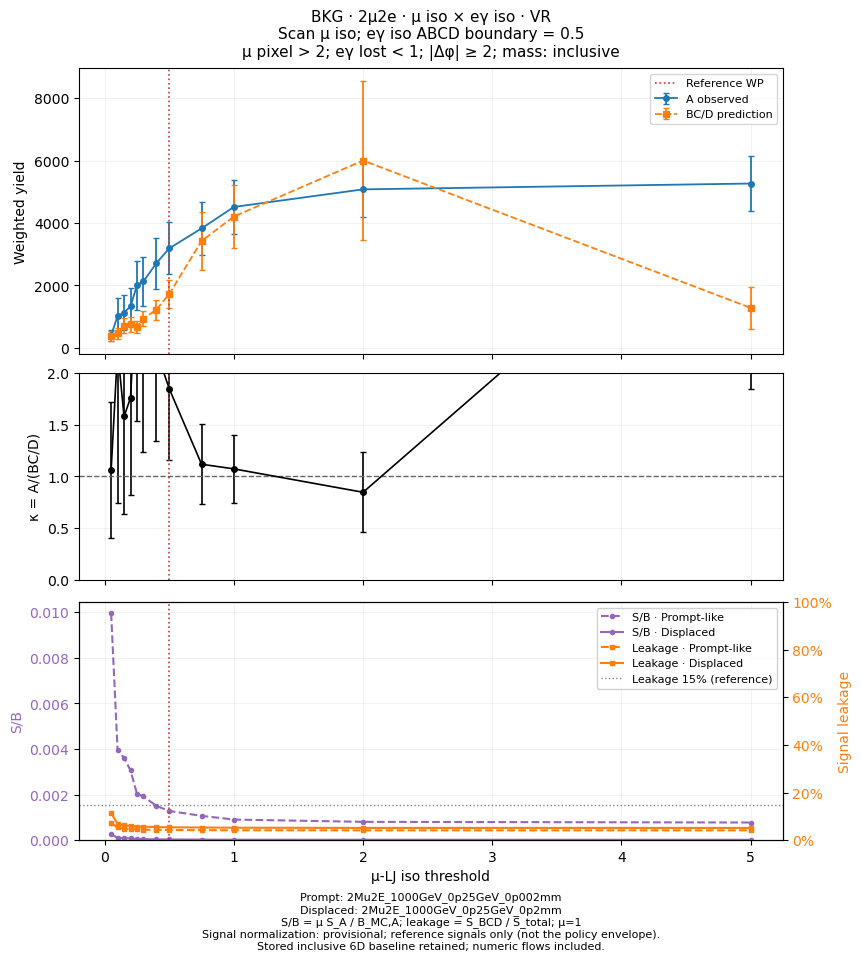

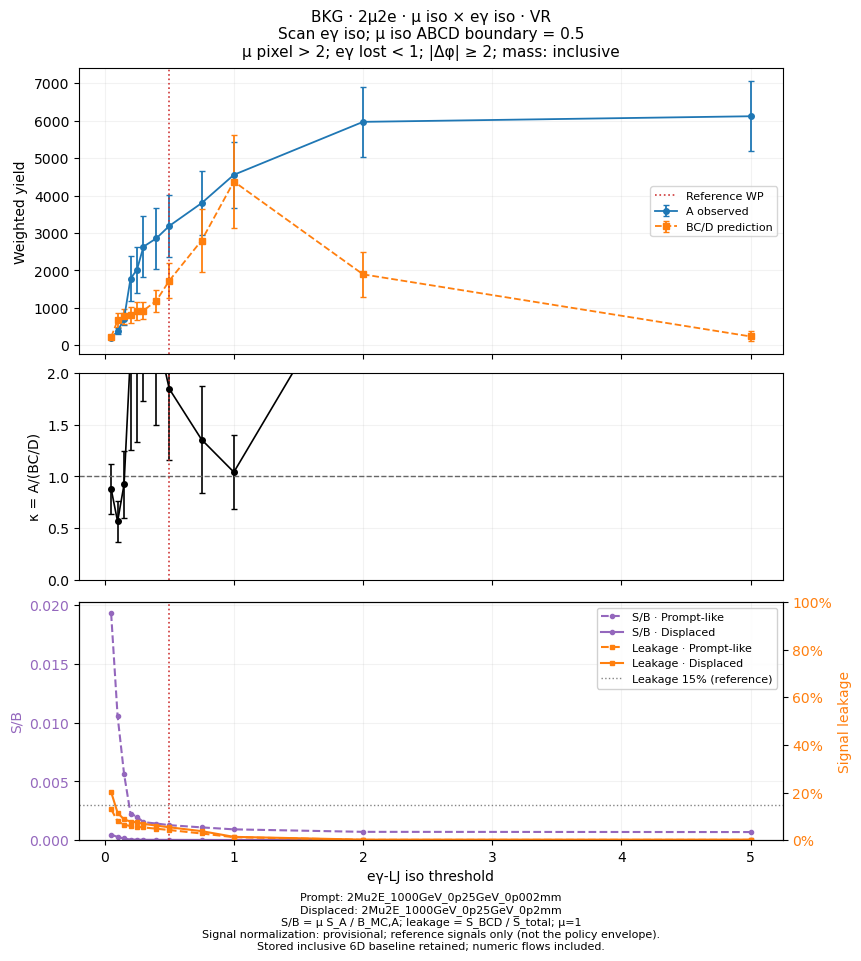

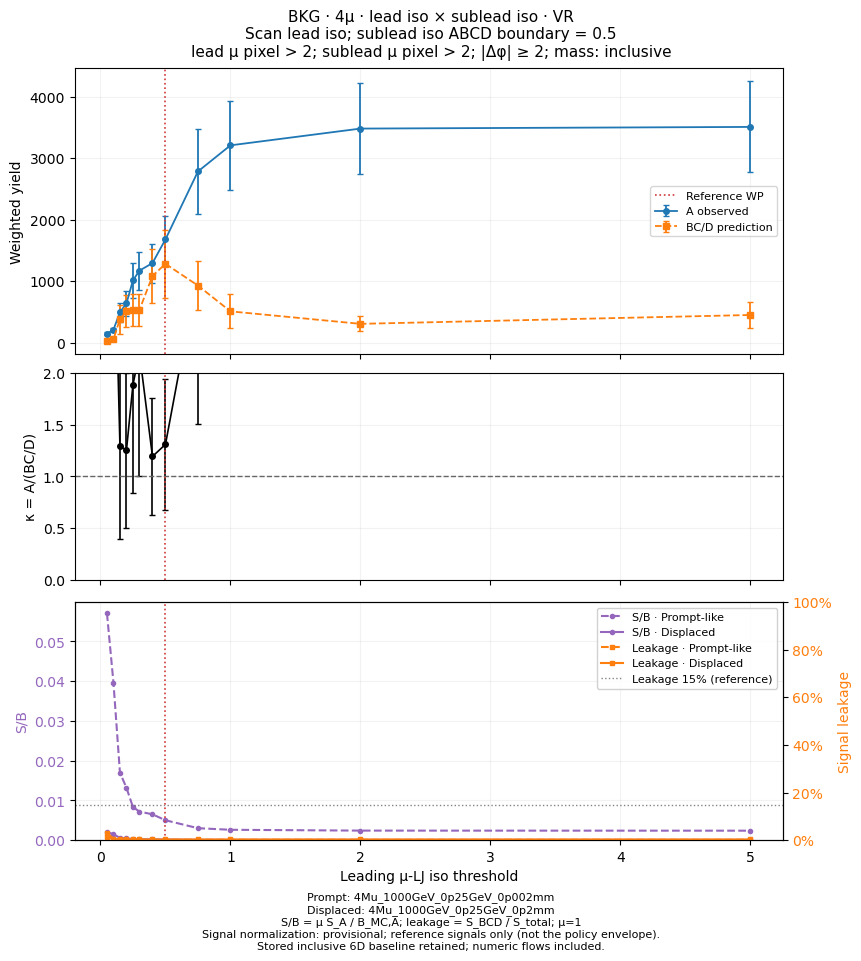

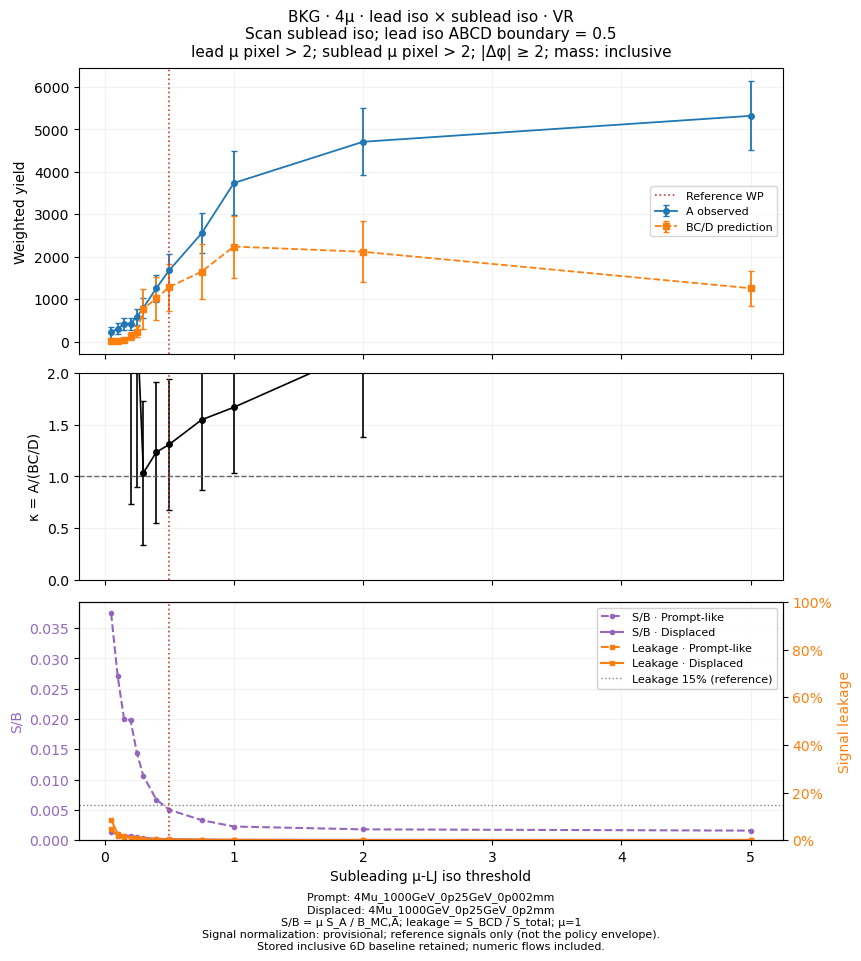

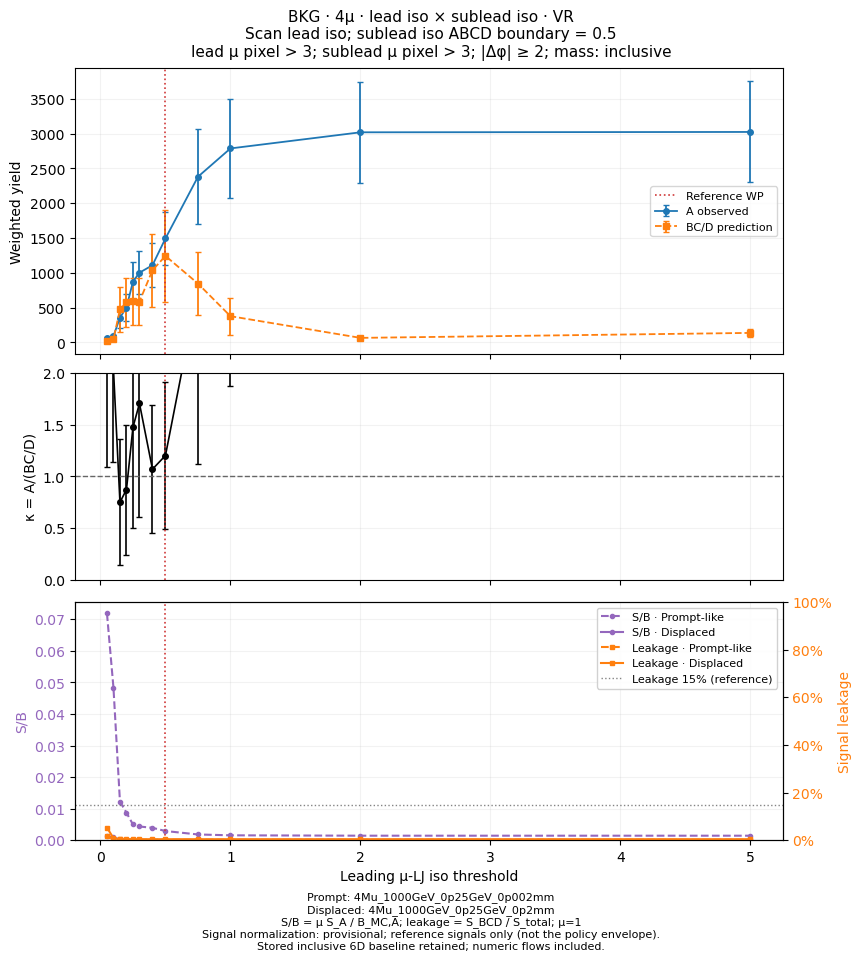

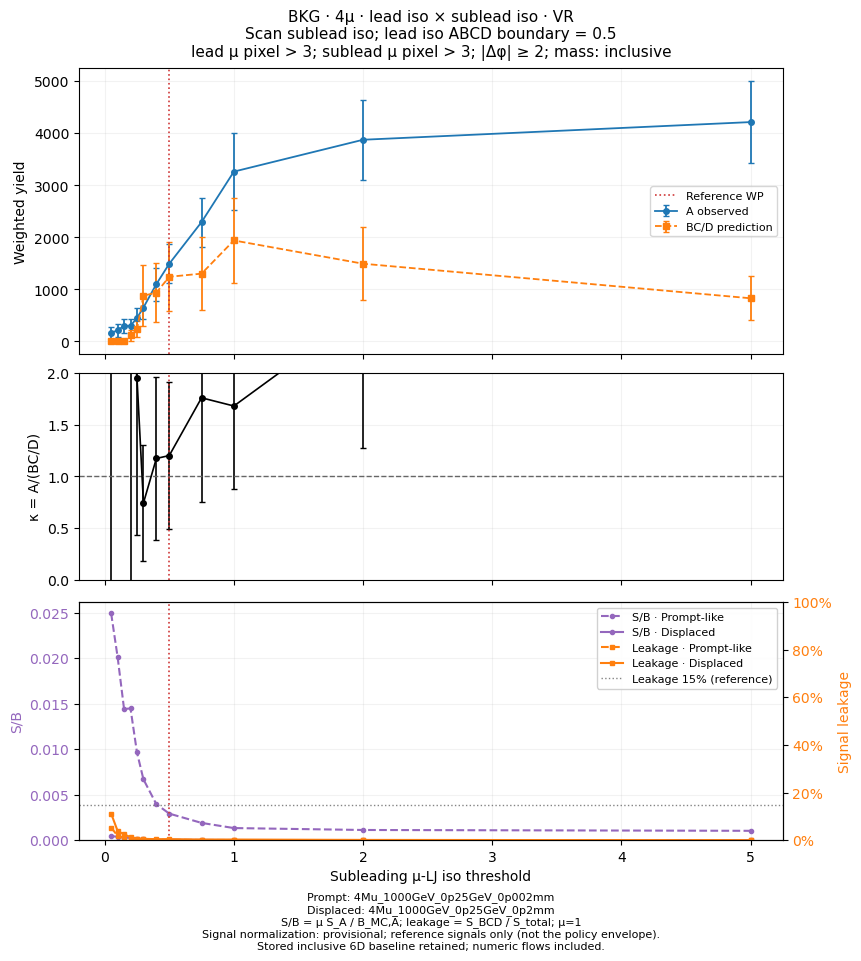

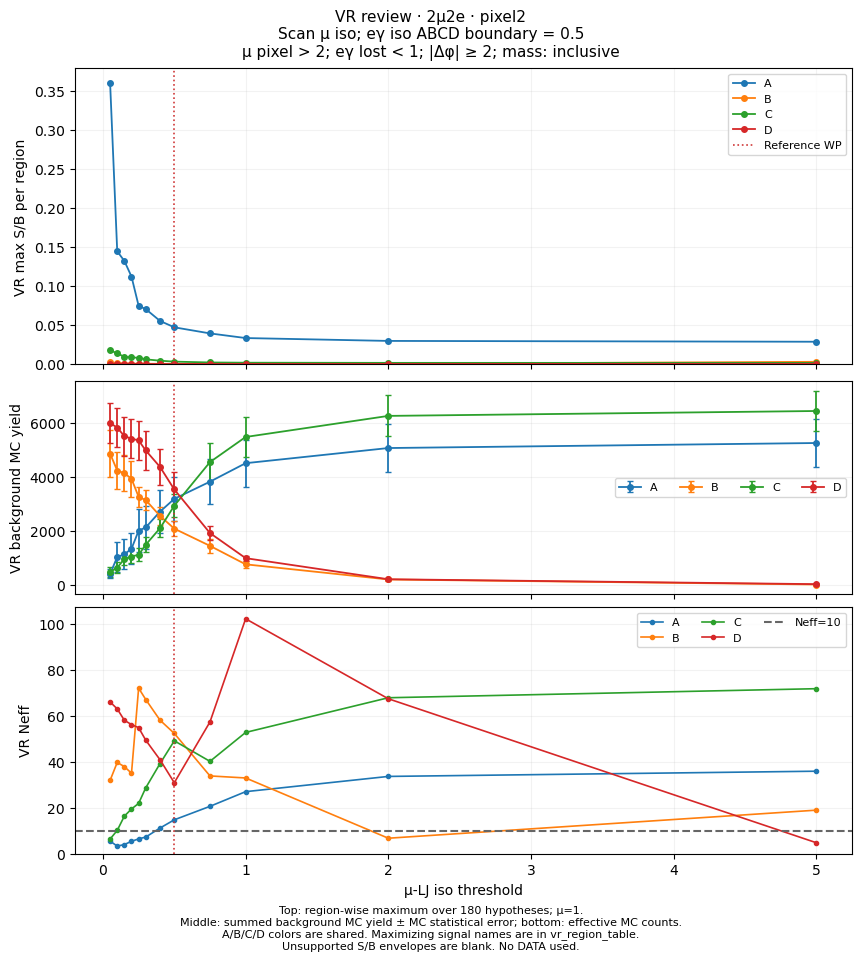

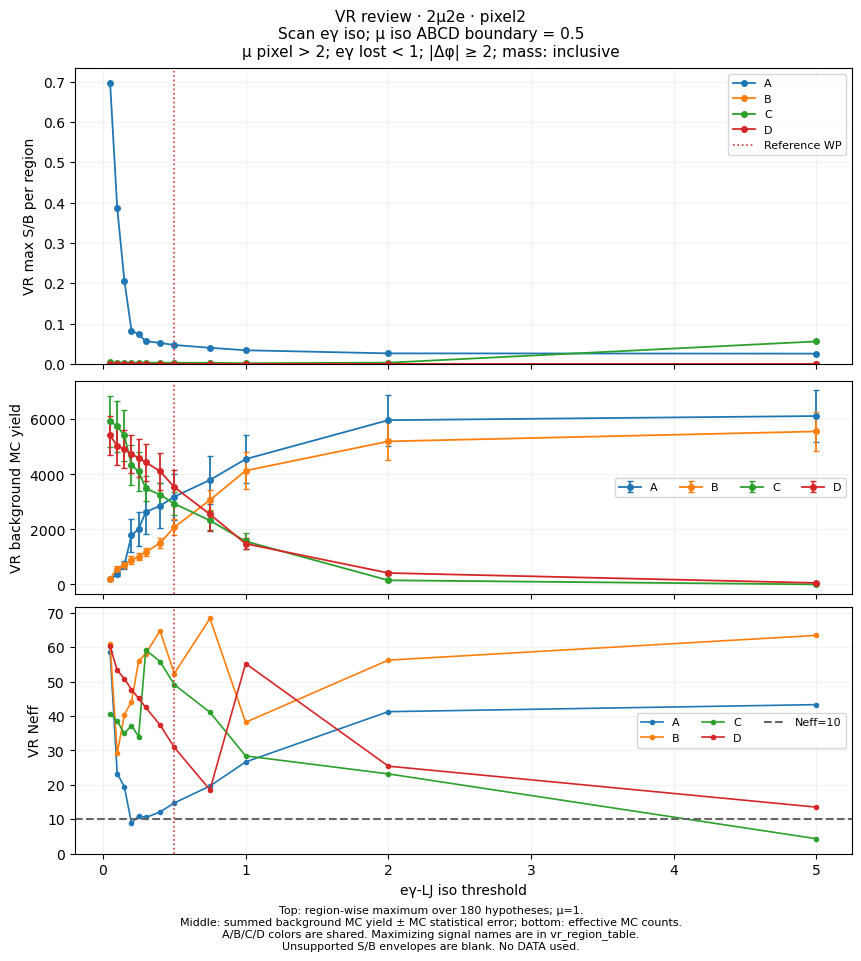

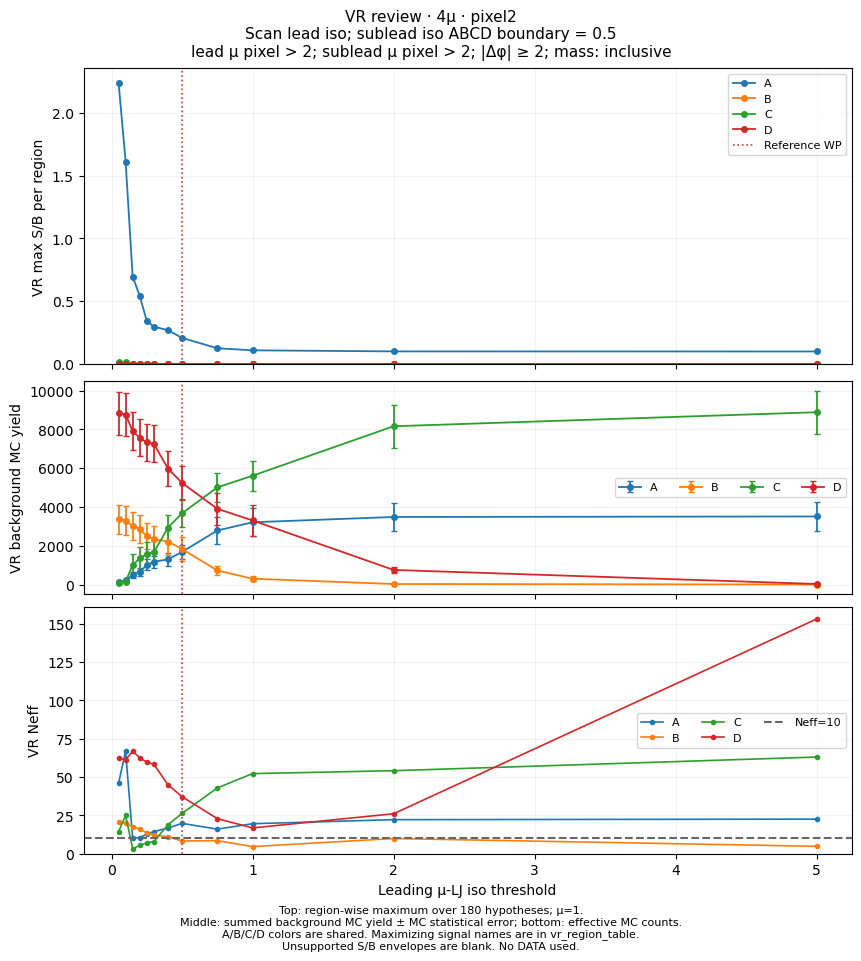

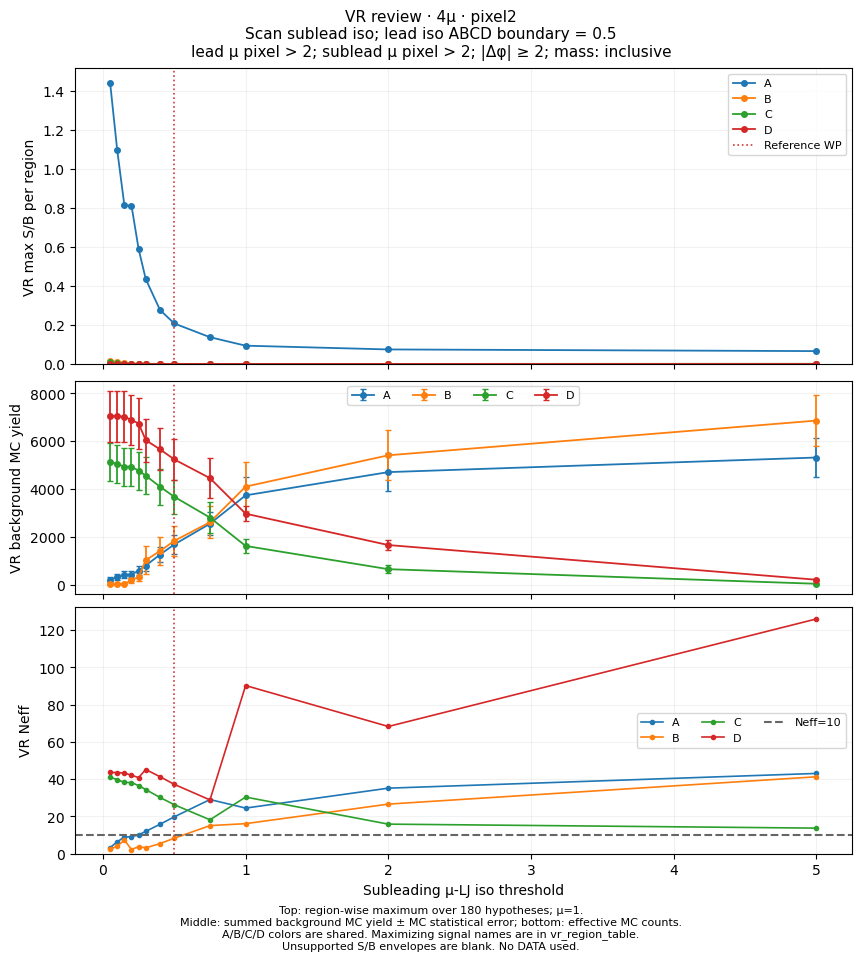

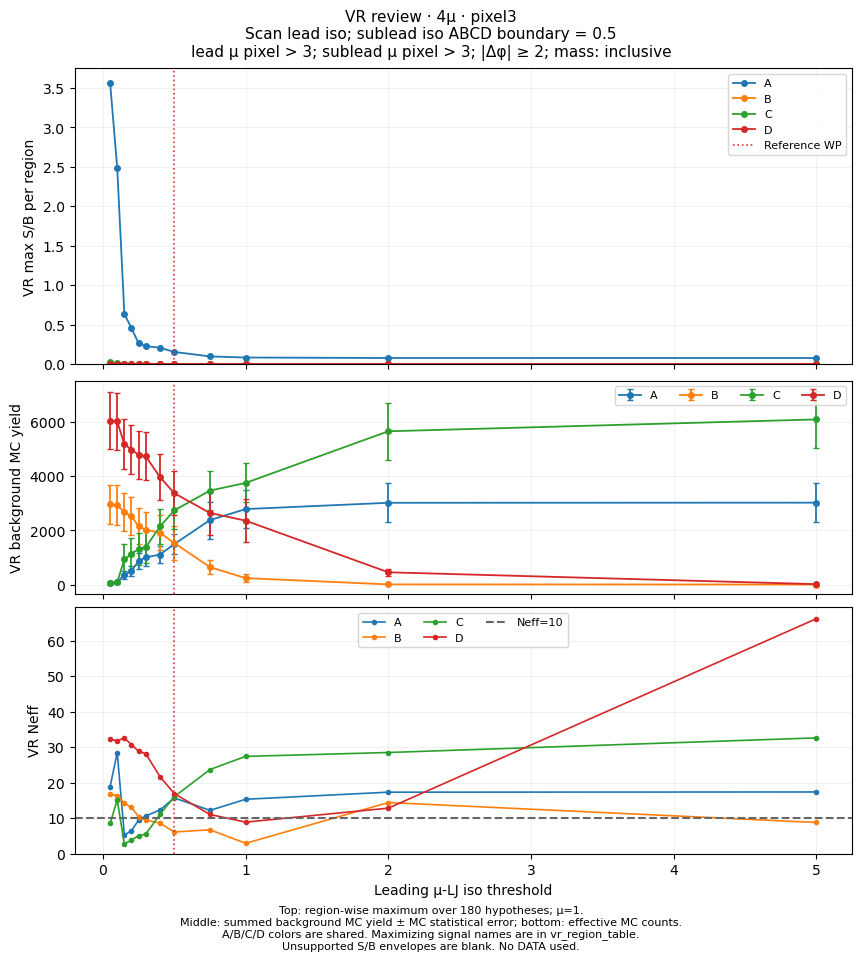

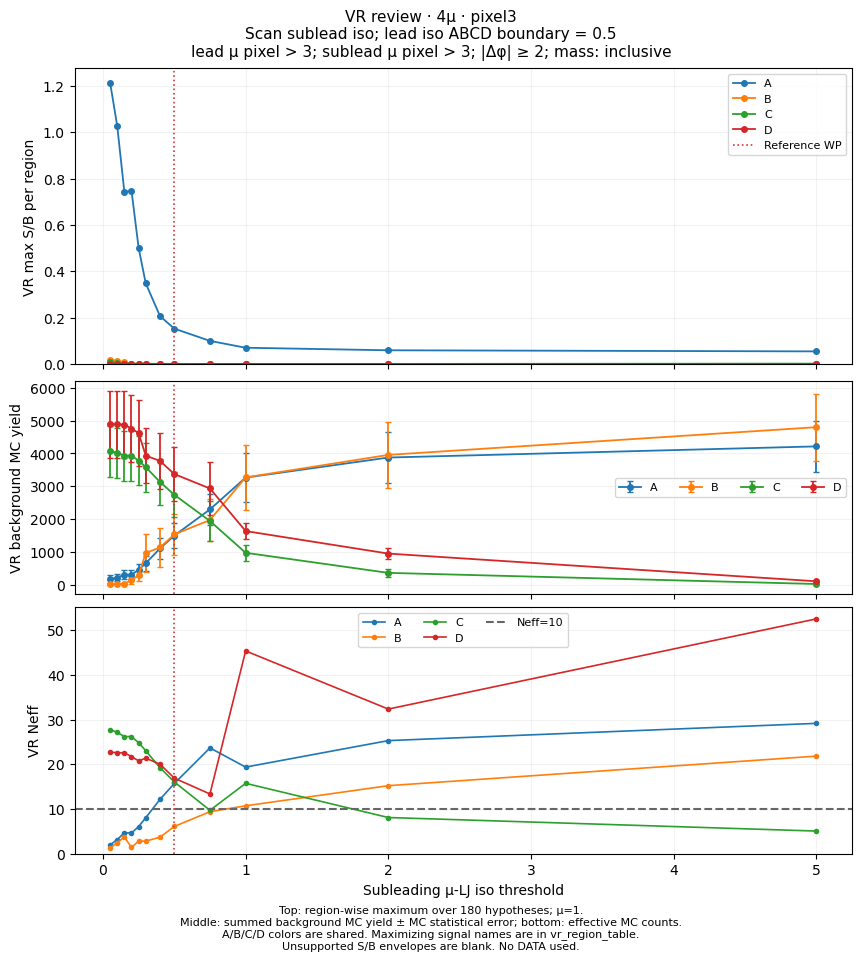

In [7]:
assert_current_calculation()
selection_table = current_selections()
review = make_review(mc_scan, signal_region_audit, selection_table)
review_policy_settings = policy_signature()
review_calculation_settings = calculation_settings
release_readiness = release_readiness_table(review, selection_table)
profile_summary = summarize_profiles(review)
with pd.option_context("display.max_columns", None):
    display(release_readiness)
    display(profile_summary)
keys = ["channel", "profile", "tx", "ty"]
review_columns = keys + [f"vr_{r}_max_s_over_b" for r in "ABCD"] + [
    "sr_max_s_over_b", "mc_VR_min_neff", "policy_pending", "sr_overlap", "yield_unsupported",
    "contamination_exceeds", "vr_unsupported_regions", "sr_unsupported_regions",
    "signal_stat_caution", "worst_signal_low_stat", "low_mc_stat", "release_candidate"]
loose_reference = review.loc[np.isclose(review.tx, .5) & np.isclose(review.ty, .5), review_columns]
with pd.option_context("display.max_columns", None):
    display(loose_reference)
    display(review[review_columns])
worst_hypotheses = review[keys+[c for c in review if c.startswith(("vr_worst_", "sr_worst_"))]].copy()
vr_region_table = summarize_vr_regions(select_policy_rows(signal_region_audit))
with pd.option_context("display.max_columns", None):
    display(vr_region_table.loc[np.isclose(vr_region_table.tx, .5) &
                                np.isclose(vr_region_table.ty, .5)])
plot_review(review)
kappa_numeric = review[keys+["mc_VR_kappa", "mc_VR_kappa_error"]].copy()
# Retain all numerical values in kappa_numeric, and signal names and yields in vr_region_table.


In [8]:
data_results, data_inventory = pd.DataFrame(), pd.DataFrame()
data_policy_settings = None
if not RUN_DATA:
    print("MC review mode: DATA has not been loaded.")
else:
    assert_current_calculation()
    if review_calculation_settings != calculation_settings:
        raise ValueError("Update the Section 6 review tables after recalculating MC.")
    if policy_signature() != review_policy_settings:
        raise ValueError("The release policy has changed: update the Section 6 review tables first.")
    current_review = make_review(mc_scan, signal_region_audit, current_selections())
    keys = ["channel", "profile", "tx", "ty"]
    requested = pd.DataFrame(APPROVED_POINTS, columns=keys).drop_duplicates()
    if requested.empty:
        raise ValueError("APPROVED_POINTS must be finalized in advance.")
    allowed = requested.merge(current_review, on=keys, how="left", validate="one_to_one")
    if not allowed.release_candidate.eq(True).all():
        raise ValueError("Some points have a pending policy, SR overlap, unsupported yields, a failed contamination criterion, or lie outside the scan.")
    results, records = [], []
    for TOPOLOGY, selected in allowed.groupby("channel", sort=False):
        saved = channel_results[TOPOLOGY]
        selected = selected.copy()
        selected["gate_passed"] = True
        data_planes = dict(saved["planes"])
        records.append(load_data_vr(data_planes, saved["profiles"], selected).assign(channel=TOPOLOGY))
        results.append(evaluate_data_scan(data_planes, selected))
        del data_planes
    data_results = pd.concat(results, ignore_index=True)
    data_inventory = pd.concat(records, ignore_index=True)
    display(data_results[keys+["data_VR_"+r for r in "ABCD"]+
        ["data_VR_pred", "data_VR_pred_error", "data_VR_kappa", "data_VR_kappa_error",
         "data_VR_min_neff", "data_VR_kappa_status"]])
    data_policy_settings = dict(calculation=calculation_settings, policy=policy_signature(),
                                points=json.dumps(APPROVED_POINTS, sort_keys=True))
    plot_closure_review(data_results, "data_VR")


MC review mode: DATA has not been loaded.


## 8. Saving the Review Records

When EXPORT_TABLES=True, save CSV tables and the policy JSON to a new directory labeled with the execution timestamp.
Topics for team discussion: protected SRs, signal hypotheses and normalization, contamination, signal statistics, MC statistics, and points to release.
Do not define the release scope by requiring κ to be close to 1.

Stop the export if the settings or policy differ from those used for the calculation. Update the review tables before exporting.
Also export profile_summary, loose_reference, and worst_hypotheses.

Save release_readiness and vr_region_table as well. Criteria based on prediction changes are excluded from the release policy.



In [9]:
if EXPORT_TABLES:
    assert_current_calculation()
    if review_calculation_settings != calculation_settings:
        raise ValueError("Update the Section 6 review tables after recalculating MC.")
    if policy_signature() != review_policy_settings:
        raise ValueError("The policy has changed. Rerun from the Section 6 review tables.")
    if not data_results.empty and data_policy_settings != dict(
            calculation=calculation_settings, policy=policy_signature(), points=json.dumps(APPROVED_POINTS, sort_keys=True)):
        raise ValueError("The DATA results to export do not match the current release policy/points.")
    destination = OUTPUT_DIR / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
    destination.mkdir(parents=True, exist_ok=False)
    tables = dict(selection=selection_table, mc_inventory=mc_inventory, review=review,
                  release_readiness=release_readiness, vr_region_table=vr_region_table,
                  profile_summary=profile_summary, loose_reference=loose_reference,
                  worst_hypotheses=worst_hypotheses,
                  signal_regions=signal_region_audit, kappa_numeric=kappa_numeric,
                  data_results=data_results, data_inventory=data_inventory)
    for name, frame in tables.items():
        frame.to_csv(destination / f"{name}.csv", index=False)
    policy = dict(calculation_settings=json.loads(calculation_settings), protected_SR=PROTECTED_SR,
        signal_normalization_verified=SIGNAL_NORMALIZATION_VERIFIED, policy_signals=POLICY_SIGNALS,
        max_region_s_over_b=MAX_REGION_S_OVER_B, gate_basis="region_s_over_b",
        min_neff=MIN_NEFF, policy_confirmed=POLICY_CONFIRMED, note=POLICY_NOTE,
        approved_points=APPROVED_POINTS, run_data=RUN_DATA, fixed_iso=.5, dphi_min=2., mass_min=None,
        review_policy_settings=json.loads(review_policy_settings), plot_iso_max=PLOT_ISO_MAX)
    (destination / "policy.json").write_text(json.dumps(policy, ensure_ascii=False, indent=2))
    print(destination)
